In [2]:
import pickle as pkl
pkl.dump(catModel,open('catModel.pkl','wb'))
pkl.dump(Transformer,open("Transformer.pkl",'wb'))
pkl.dump(encoder,open("encoder.pkl",'wb'))
pkl.dump(numCols,open("numCols.pkl","wb"))
pkl.dump(textCols,open("textCols.pkl","wb"))
pkl.dump(bounds,open("bounds.pkl","wb"))

NameError: name 'catModel' is not defined

In [53]:
import pandas as pd
import numpy as np
import numpy as np
import xgboost
from xgboost import XGBClassifier
from matplotlib import pyplot as plt
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from builtins import set,list

# from 
from sklearn.preprocessing import PowerTransformer,LabelEncoder,StandardScaler,OrdinalEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
# from sklearn.
from sklearn.metrics import confusion_matrix,recall_score,accuracy_score,precision_score,classification_report
import seaborn as sns


In [54]:
studentOutcome=pd.read_csv("Student Outcome dataset.csv")

In [55]:
studentOutcome.columns=studentOutcome.columns.str.replace('\t','',regex=False)

In [56]:
studentOutcome

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [57]:
# checking null values
studentOutcome.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [58]:
# describe
studentOutcome.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [59]:
# rename columns
studentOutcome.rename(columns={"Curricular units 2nd sem (evaluations)":"Curricular units sec sem (evaluations)"},inplace=True)

In [60]:
studentOutcome.rename(
            columns=
            {"Curricular units 2nd sem (credited)":"Curricular units sec sem (credited)",
            "Curricular units 2nd sem (grade)":"Curricular units sec sem (grade)",
            "Curricular units 2nd sem (approved)":"Curricular units sec sem (approved)",
            "Curricular units 2nd sem (without evaluations)":"Curricular units sec sem (without evaluations)",
            "Curricular units 2nd sem (enrolled)":"Curricular units Sec sem (enrolled)",
            "Course":"Course Fee",
              "Mother's qualification":"Mothers qualification",
              "Father's qualification":"Fathers qualification",
            "Curricular units 2nd sem (without evaluations)":"Curricular units sec sem (without evaluations)"},inplace=True )




In [61]:
# extracted cat columns
numCols=['Application mode','Application order','Course Fee','Previous qualification (grade)','Mothers qualification',	
'Fathers qualification','Curricular units sec sem (grade)','Unemployment rate','GDP'
]
# allCols=studentOutcome.columns.tolist()
# catCols=list(set(allCols)-set(numCols))

In [62]:
studentOutcome

,Marital status,Application mode,Application order,Course Fee,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mothers qualification,Fathers qualification,...,Curricular units sec sem (credited),Curricular units Sec sem (enrolled),Curricular units sec sem (evaluations),Curricular units sec sem (approved),Curricular units sec sem (grade),Curricular units sec sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [63]:
studentOutcome.to_csv("test dataset.csv")

In [64]:
# extract Categorical columns
textCols=[]
for colCat in studentOutcome.columns:
    if colCat not in numCols:
        textCols.append(colCat)

In [15]:
textCols

['Marital status',
 'Daytime/evening attendance',
 'Previous qualification',
 'Nacionality',
 "Mother's occupation",
 "Father's occupation",
 'Admission grade',
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units sec sem (credited)',
 'Curricular units Sec sem (enrolled)',
 'Curricular units sec sem (evaluations)',
 'Curricular units sec sem (approved)',
 'Curricular units sec sem (without evaluations)',
 'Inflation rate',
 'Target']

In [65]:
# Split data
x=studentOutcome.drop(columns=['Target'])
y=studentOutcome['Target']
xTrain,xTest,yTrain,yTest=train_test_split(x,y,test_size=0.3,random_state=67)

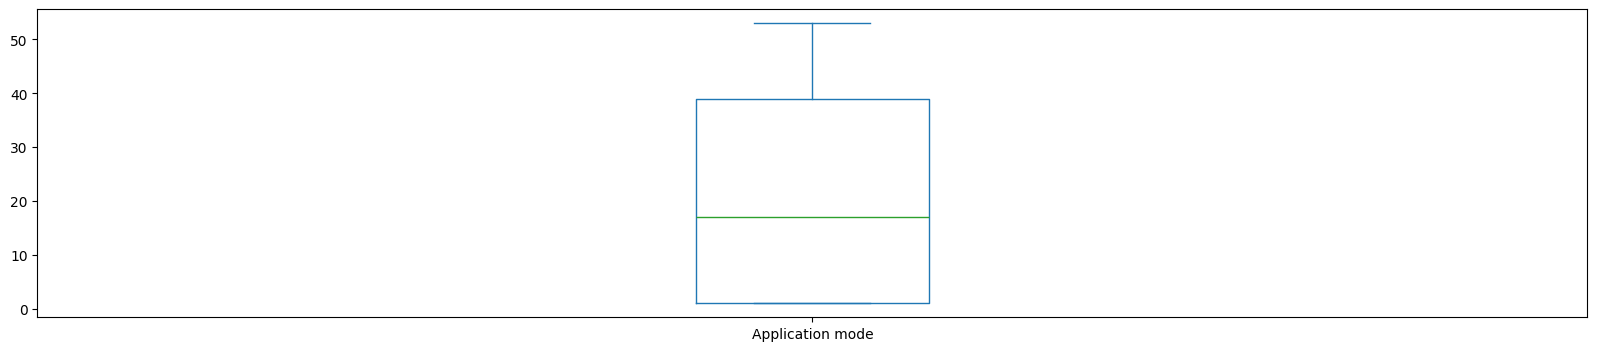

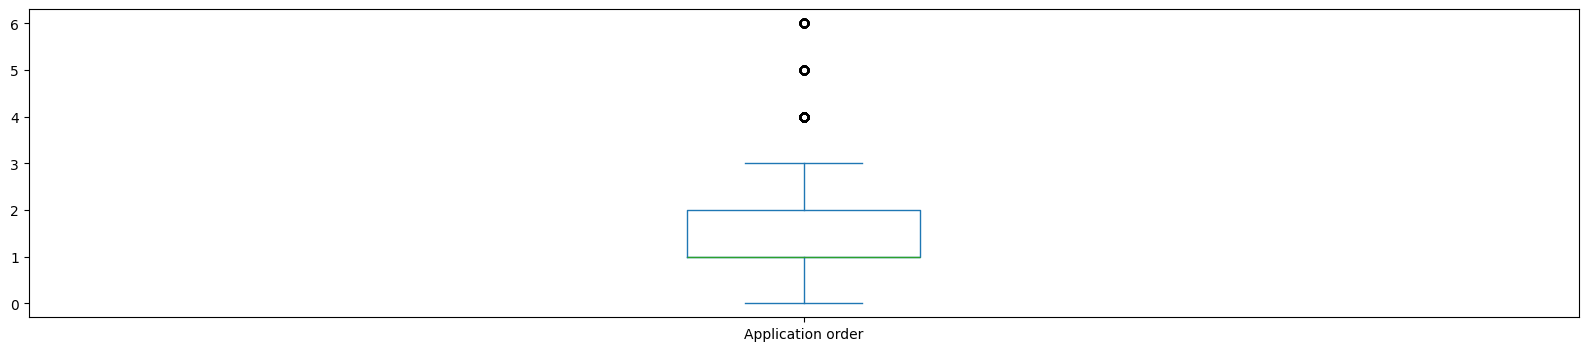

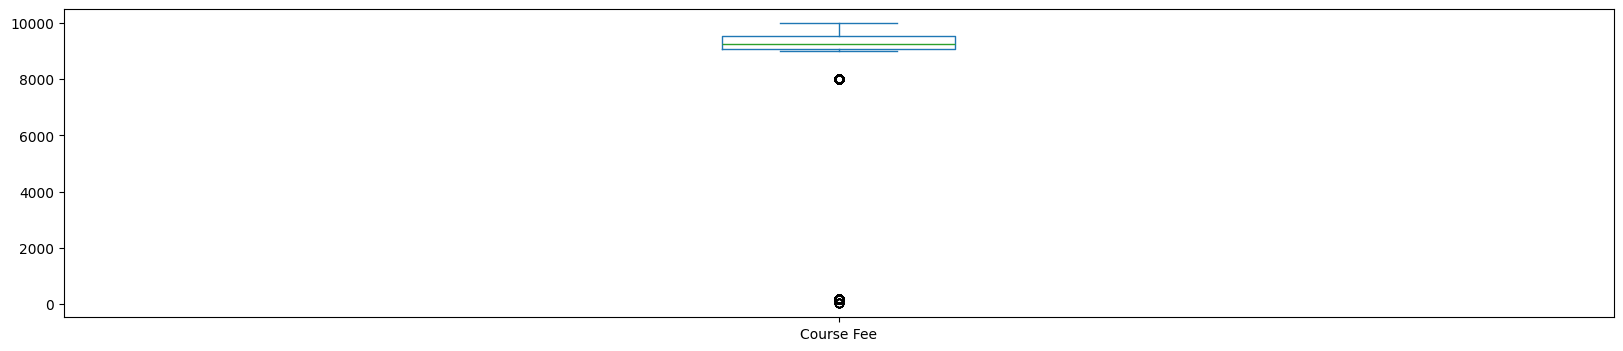

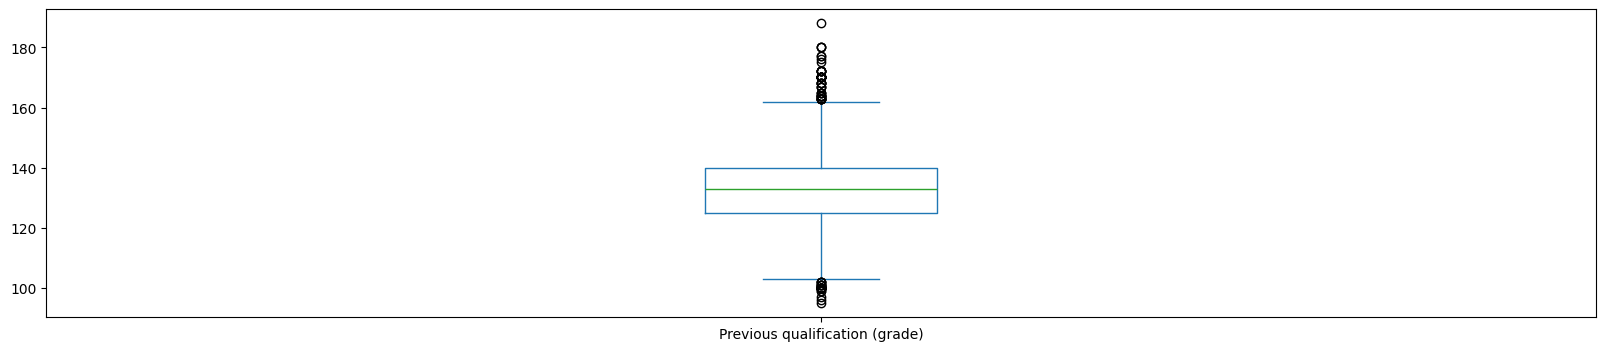

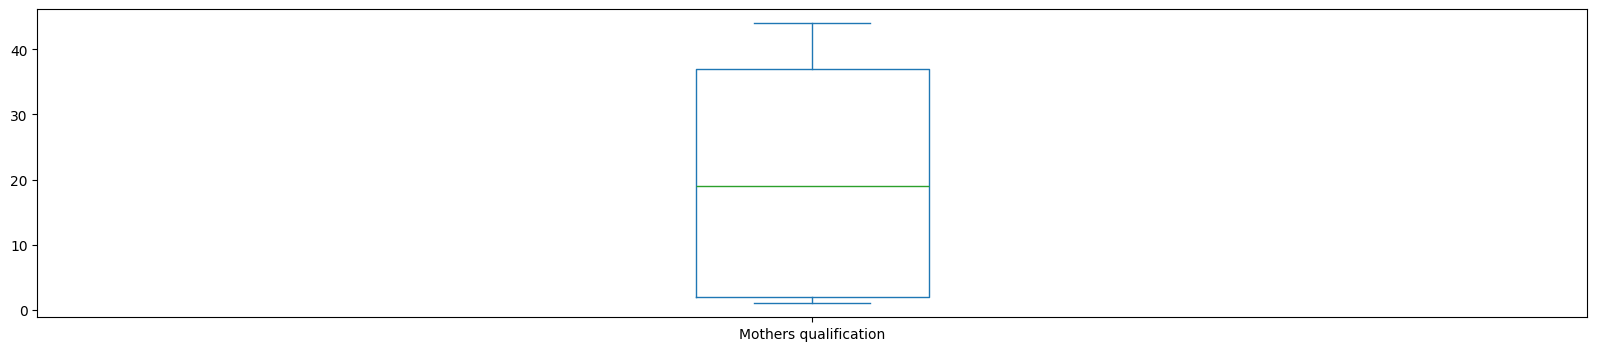

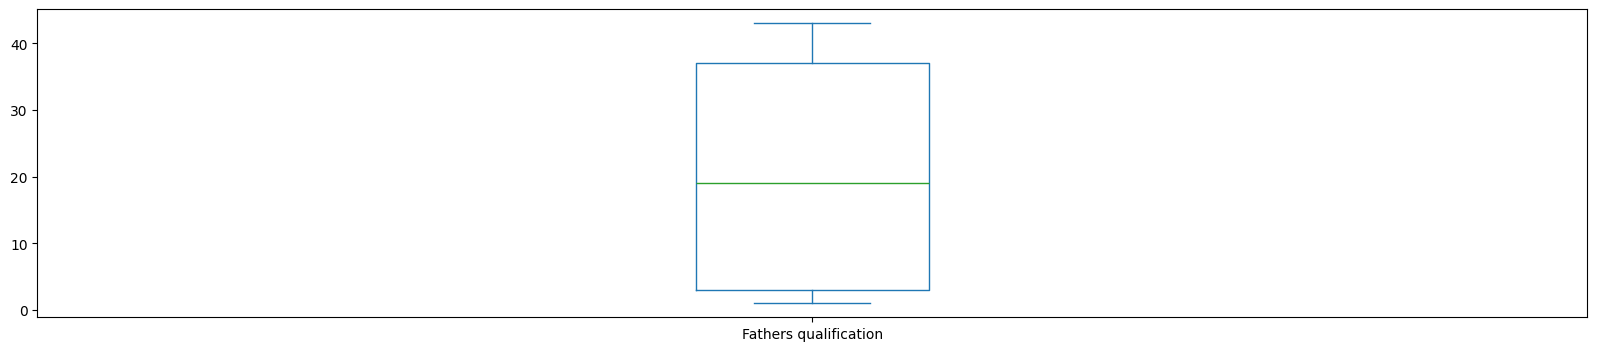

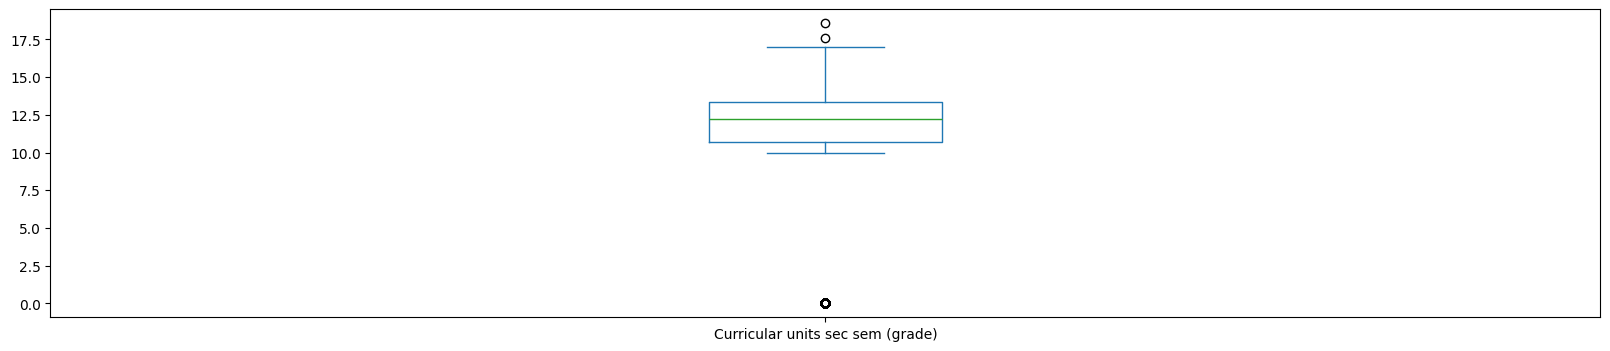

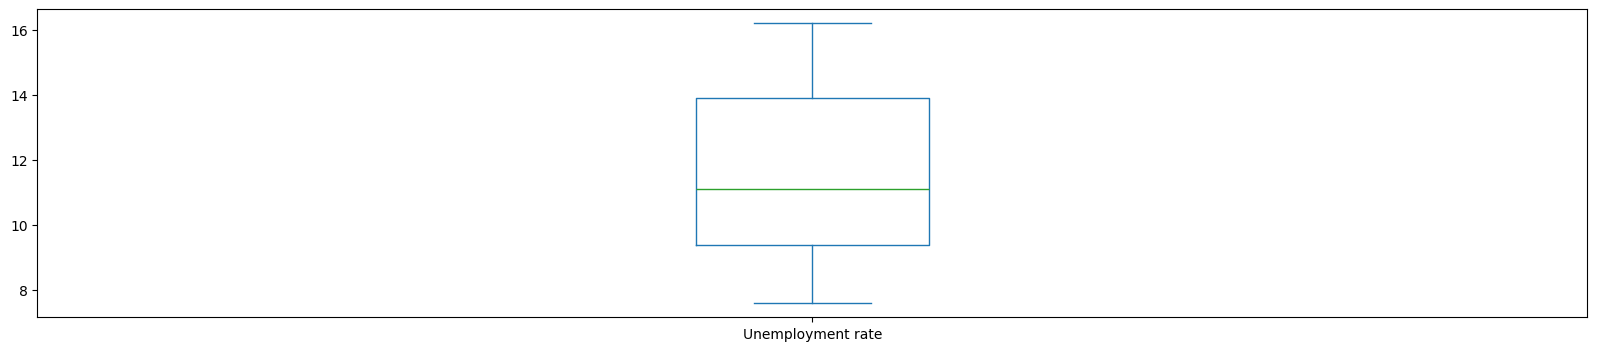

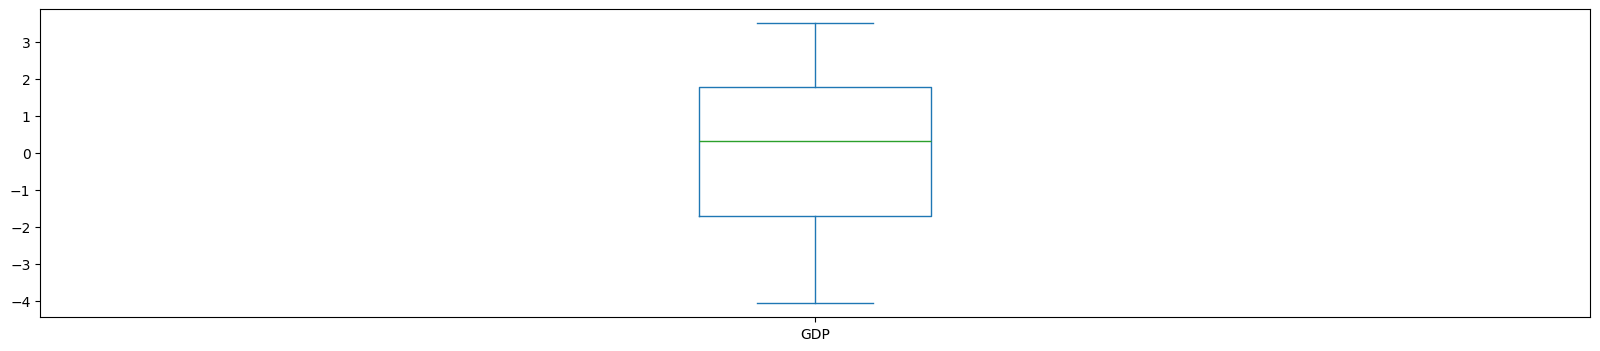

In [66]:
for box in numCols:
    plt.figure(figsize=(20,4))
    xTrain[box].plot(kind="box")

In [67]:
bounds={}
for col in numCols:
        Q1 = xTrain[col].quantile(0.25)
        Q3 = xTrain[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
    

        has_outliers = (
            (xTrain[col] < lower_bound) | 
            (xTrain[col] > upper_bound)
        ).any()
        bounds[col]={"lower":lower_bound,"upper":upper_bound}

        if has_outliers:
            xTrain[col] = xTrain[col].clip(lower=lower_bound, upper=upper_bound)
            xTest[col] = xTest[col].clip(lower=lower_bound, upper=upper_bound)
pkl.dump(bounds,open("bounds.pkl","wb"))

In [68]:
print(numCols)

['Application mode', 'Application order', 'Course Fee', 'Previous qualification (grade)', 'Mothers qualification', 'Fathers qualification', 'Curricular units sec sem (grade)', 'Unemployment rate', 'GDP']


In [69]:
xTrain=pd.DataFrame(xTrain)

In [22]:
# xTest=Transformer.transform(xTest)

In [70]:
# encoder for Target Var
encoder=LabelEncoder()
yTrain=encoder.fit_transform(yTrain)

In [71]:
yTrain=pd.DataFrame(yTrain)

In [72]:
# encode ytest data
yTest=encoder.fit_transform(yTest)

In [73]:
# check whether relationship is linear or not
concDataset=pd.concat([xTrain.reset_index(drop=True),yTrain.reset_index(drop=True)],axis=1) # Concatenated df
concDataset.corr()

,Marital status,Application mode,Application order,Course Fee,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mothers qualification,Fathers qualification,...,Curricular units sec sem (credited),Curricular units Sec sem (enrolled),Curricular units sec sem (evaluations),Curricular units sec sem (approved),Curricular units sec sem (grade),Curricular units sec sem (without evaluations),Unemployment rate,Inflation rate,GDP,0
Marital status,1.000000,0.259670,-0.130784,-0.028085,-0.275208,0.047988,-0.011983,0.000390,0.205136,0.146118,...,0.048034,0.028687,0.018772,-0.052742,-0.089359,0.028214,-0.034367,-0.002742,-0.023545,-0.102212
Application mode,0.259670,1.000000,-0.318169,-0.053594,-0.297583,0.418841,-0.027213,-0.002405,0.118512,0.074437,...,0.238102,0.141067,0.176569,-0.066097,-0.138689,0.055833,0.081888,-0.028765,-0.024747,-0.216497
Application order,-0.130784,-0.318169,1.000000,0.105654,0.177135,-0.203565,-0.075886,-0.014671,-0.079639,-0.064209,...,-0.149418,-0.001844,-0.075047,0.059590,0.062607,-0.021109,-0.095486,-0.004108,0.034572,0.099608
Course Fee,-0.028085,-0.053594,0.105654,1.000000,0.042897,-0.105880,-0.032156,-0.021440,0.022568,0.021839,...,-0.106196,0.223911,0.101281,0.142343,0.211537,0.012005,-0.007134,0.039109,-0.023543,0.010445
Daytime/evening attendance,-0.275208,-0.297583,0.177135,0.042897,1.000000,-0.066078,0.041569,0.024299,-0.211104,-0.146031,...,-0.109218,-0.006527,0.024575,0.039284,0.079463,-0.015867,0.075332,-0.011385,0.022295,0.071828
Previous qualification,0.047988,0.418841,-0.203565,-0.105880,-0.066078,1.000000,0.107748,-0.032952,-0.023598,-0.011703,...,0.135294,0.059968,0.103720,-0.017437,-0.017004,-0.000845,0.093308,-0.059657,0.077143,-0.062702
Previous qualification (grade),-0.011983,-0.027213,-0.075886,-0.032156,0.041569,0.107748,1.000000,0.025687,-0.055216,-0.017116,...,-0.006921,-0.014990,-0.044870,0.057063,0.113043,-0.006848,0.034815,0.035275,-0.075393,0.103355
Nacionality,0.000390,-0.002405,-0.014671,-0.021440,0.024299,-0.032952,0.025687,1.000000,-0.049253,-0.092167,...,-0.009510,-0.017971,-0.032966,-0.012350,-0.002330,-0.008991,-0.007851,-0.013549,0.040796,0.001406
Mothers qualification,0.205136,0.118512,-0.079639,0.022568,-0.211104,-0.023598,-0.055216,-0.049253,1.000000,0.534648,...,0.031618,0.036176,0.025412,-0.011285,-0.032152,0.027430,-0.126052,0.053409,-0.079510,-0.048164
Fathers qualification,0.146118,0.074437,-0.064209,0.021839,-0.146031,-0.011703,-0.017116,-0.092167,0.534648,1.000000,...,0.032648,0.028267,0.014031,0.019669,0.001465,-0.010835,-0.083365,0.051466,-0.072601,0.017677


In [74]:
# check records per class
studentOutcome['Target'].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [84]:
# Apply sa,mple weight due to imbalance
sample_weights=compute_sample_weight(class_weight="balanced",y=yTrain)

In [87]:
# model
catModel = XGBClassifier(
    learning_rate = 0.01,
    reg_lambda=0.1,
    reg_alpha=0.1,
    max_depth     = 3,
    n_estimators  = 1000,
    random_state  = 50
)

catModel.fit(xTrain, yTrain,sample_weight=sample_weights)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [88]:
# predict
prediction=catModel.predict(xTest)

In [89]:
# prediction
prediction=catModel.predict(xTest)

In [91]:
report=classification_report(yTest,prediction,target_names=encoder.classes_,output_dict=True)

In [92]:
reportFrame=pd.DataFrame(report).transpose()

In [93]:
# classificatiion Report
reportFrame

,precision,recall,f1-score,support
Dropout,0.829132,0.714976,0.767834,414.000000
Enrolled,0.469027,0.628458,0.537162,253.000000
Graduate,0.849684,0.812405,0.830626,661.000000
accuracy,0.746988,0.746988,0.746988,0.746988
macro avg,0.715947,0.718613,0.711874,1328.000000
weighted avg,0.770757,0.746988,0.755143,1328.000000
